# 01 · Auditoría y diccionario de datos

Objetivo: identificar qué representa cada observación antes de modelar. Este notebook lee los cuatro originales sin alterarlos y exporta tablas auditables a `reports/audit/`.

**Una curva ≠ una línea ≠ un paciente.** Los SIDM permiten contar modelos celulares y agrupar validación; la independencia por donante requiere metadatos adicionales. No sumar el archivo T98G ni las dos versiones del subconjunto.

El protocolo ya está en `config.json`: outcome `LN_IC50`, QC `RMSE ≤ 0.3`. El sitio oficial [Sanger](https://depmap.sanger.ac.uk/documentation/datasets/drug-sensitivity/) define columnas y explica ese umbral. Los gráficos descriptivos no se usan para buscar un umbral que mejore test.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "config.json").is_file() and (p / "src/gbm_drug_response").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Abra este notebook desde el repositorio gbm-drug-response.")
sys.path.insert(0, str(ROOT / "src"))
from gbm_drug_response.data import load_config
CFG = load_config(ROOT)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False})
display(CFG)

{'seed': 42,
 'target': 'LN_IC50',
 'group': 'SANGER_MODEL_ID',
 'qc_rmse_max': 0.3,
 'qc_sensitivity_thresholds': [0.15, 0.2, 0.25, 0.3],
 'test_size': 0.2,
 'cv_folds': 4,
 'metadata_features': ['DRUG_ID', 'CANCER_TYPE'],
 'molecular_drug_ids': [],
 'molecular_max_drugs': 3,
 'molecular_min_development_lines': 25,
 'molecular_min_test_lines': 5,
 'bootstrap_repetitions': 1000}

## Lectura y verificación completa

La primera lectura del Excel grande puede tardar alrededor de un minuto. Se normalizan espacios vacíos, tipos numéricos e identificadores. La comparación entre archivos usa todas las columnas, enlazadas por `NLME_CURVE_ID`, con tolerancia numérica de 1e-12.

El diccionario completo, los hashes y las comprobaciones se guardan automáticamente. La implementación reutilizable está en `src/gbm_drug_response/data.py`.

In [2]:
from gbm_drug_response.data import audit, data_dictionary, quality_flags
frames, inventory, retention = audit(ROOT)
display(inventory)
glioma = frames["glioma_csv"]
display(json.loads((ROOT / "reports/audit/relationships.json").read_text()))

,dataset,file,rows,columns,cell_lines,drug_ids,drug_names,duplicate_rows,duplicate_curve_ids,duplicate_model_drug
0,gdsc2,GDSC2_fitted_dose_response_27Oct23.xlsx,242036,16,969,295,286,0,0,0
1,glioma_csv,GBMGliomafiltrado.csv,12001,16,51,295,286,0,0,0
2,glioma_xlsx,GBMGliomafiltrado.xlsx,12001,16,51,295,286,0,0,0
3,t98g,Aislados T98G - Hoja 1.csv,280,16,1,280,271,0,0,0


{'glioma_csv_equals_xlsx': True,
 'glioma_subset_gdsc2': True,
 't98g_subset_glioma': True,
 'float_tolerance': 1e-12,
 'originals_changed': False}

## Diccionario y faltantes

`PUTATIVE_TARGET` describe una diana del medicamento; el outcome de aprendizaje es `LN_IC50`.
`PATHWAY_NAME` es una anotación del fármaco, no actividad de vías medida en cada línea.
La columna `DATASET` también forma parte de las 16 columnas. Los ejemplos provienen de los archivos reales.

In [3]:
dictionary = data_dictionary(glioma)
display(dictionary[["column", "definition_es", "role", "unit", "dtype", "n_missing", "n_unique_nonmissing"]])
display(pd.concat({name: data_dictionary(df).set_index("column").n_missing
                   for name, df in frames.items()}, axis=1).loc[lambda x: x.sum(axis=1) > 0])
display(glioma.groupby("CANCER_TYPE").agg(curves=("NLME_CURVE_ID", "size"),
                                          models=("SANGER_MODEL_ID", "nunique")))

,column,definition_es,role,unit,dtype,n_missing,n_unique_nonmissing
0,DATASET,Colección de origen,procedencia,texto,string,0,1
1,NLME_RESULT_ID,Identificador del conjunto de ajustes,identificador,ID,string,0,1
2,NLME_CURVE_ID,Identificador de curva ajustada,clave de observación,ID,string,0,12001
3,CELL_LINE_NAME,Nombre de línea celular,identificador,texto,string,0,51
4,SANGER_MODEL_ID,Identificador Sanger del modelo celular,grupo de validación / unión,ID,string,0,51
5,CANCER_TYPE,Tipo de cáncer anotado,covariable opcional,categoría,string,0,2
6,DRUG_ID,Identificador del fármaco ensayado,unión / predictor para fármacos conocidos,ID,string,0,295
7,DRUG_NAME,Nombre del fármaco,anotación,texto,string,0,286
8,PUTATIVE_TARGET,Diana farmacológica propuesta,anotación del fármaco,texto,string,1193,184
9,PATHWAY_NAME,Vía de la diana farmacológica,anotación; no actividad de vías celulares,categoría,string,0,24


,gdsc2,glioma_csv,glioma_xlsx,t98g
column,,,,
PUTATIVE_TARGET,27872,1193,1193,38


,curves,models
CANCER_TYPE,,
Glioblastoma,8796,37
Glioma,3205,14


## Claves, cobertura y nombres de fármacos repetidos

`SANGER_MODEL_ID + DRUG_ID` identifica una combinación ensayada en estos adjuntos. Los nombres repetidos con IDs distintos se conservan: Sanger documenta múltiples entradas debidas a su seguimiento interno. No fusionarlas por nombre sin revisar el protocolo experimental.

,líneas por fármaco
count,295.000000
mean,40.681356
std,10.574975
min,16.000000
25%,30.000000
50%,47.000000
75%,50.000000
max,51.000000


,DRUG_NAME,DRUG_ID,MIN_CONC,MAX_CONC
0,Docetaxel,1007,0.000013,0.0125
1,Selumetinib,1062,0.010005,10.0000
2,Oxaliplatin,1089,0.010005,10.0000
3,Fulvestrant,1200,0.001001,1.0000
4,Uprosertib,1553,0.010005,10.0000
5,GSK343,1627,0.001001,1.0000
6,Selumetinib,1736,0.010005,10.0000
7,Acetalax,1803,0.030016,30.0000
8,Acetalax,1804,0.030016,30.0000
9,Oxaliplatin,1806,0.020011,20.0000


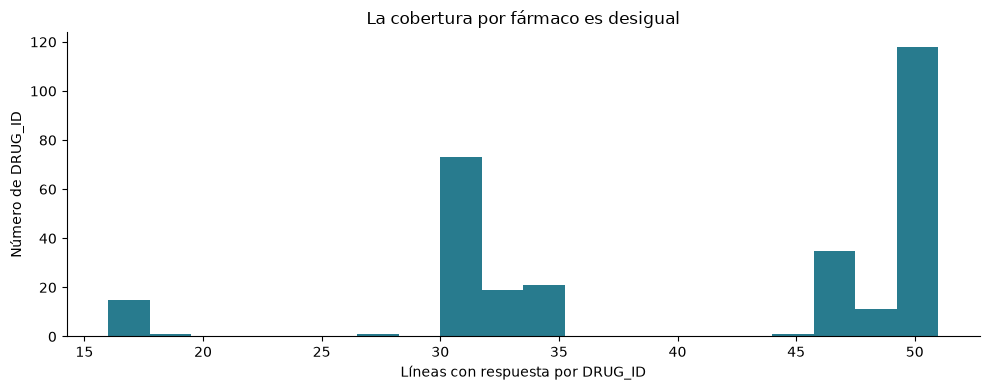

In [4]:
coverage = pd.read_csv(ROOT / "reports/audit/drug_coverage.csv")
aliases = pd.read_csv(ROOT / "reports/audit/multiple_drug_ids.csv")
display(coverage.n_lines.describe().to_frame("líneas por fármaco"))
display(aliases)
fig, ax = plt.subplots()
ax.hist(coverage.n_lines, bins=20, color="#287b8e")
ax.set(xlabel="Líneas con respuesta por DRUG_ID", ylabel="Número de DRUG_ID",
       title="La cobertura por fármaco es desigual")
plt.tight_layout()
plt.show()

## Calidad preespecificada

Conservar RMSE en [0, 0.3], outcome finito, AUC en [0, 1], concentraciones positivas y ordenadas e identificadores esenciales completos. Los criterios inválidos se exportan como banderas. Los umbrales más estrictos sólo muestran retención; no se optimizan con métricas del modelo.

**RMSE de curva experimental** y **RMSE de predicción** son cantidades diferentes. Un buen ajuste de curva no garantiza que la IC50 esté dentro de las concentraciones estudiadas.

,rmse_max,retained_rows,removed_rows,retained_lines
0,0.15,11327,674,51
1,0.20,11839,162,51
2,0.25,11968,33,51
3,0.30,12001,0,51


,filas
invalid_target,0
invalid_rmse,0
invalid_auc,0
invalid_concentrations,0
missing_key,0
keep,12001
ic50_below_range,36
ic50_above_range,9181


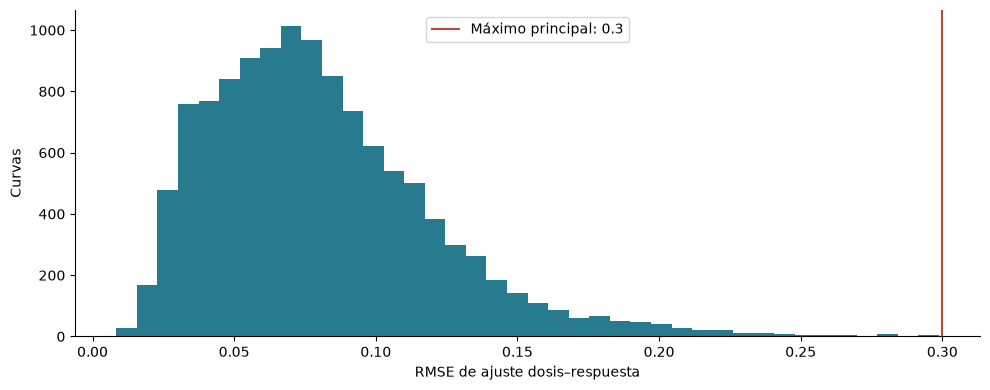

,LN_IC50,AUC,RMSE,MIN_CONC,MAX_CONC
count,12001.000000,12001.000000,12001.000000,12001.000000,12001.000000
mean,3.166474,0.893946,0.080527,0.022428,22.683581
std,2.722019,0.129635,0.039868,0.154617,154.510888
min,-7.037283,0.025104,0.008388,0.000010,0.010000
25%,1.922250,0.863702,0.051589,0.003002,3.000000
50%,3.586813,0.945837,0.074331,0.010005,10.000000
75%,5.054487,0.973702,0.101648,0.010005,10.000000
max,13.558148,0.993346,0.298767,2.001054,2000.000000


In [5]:
flags = quality_flags(glioma, CFG["qc_rmse_max"])
display(retention)
display(flags.sum().rename("filas").to_frame())
fig, ax = plt.subplots()
ax.hist(glioma.RMSE, bins=40, color="#287b8e")
ax.axvline(CFG["qc_rmse_max"], color="#b84b3d", label="Máximo principal: 0.3")
ax.set(xlabel="RMSE de ajuste dosis–respuesta", ylabel="Curvas")
ax.legend()
plt.tight_layout()
plt.show()
display(glioma[["LN_IC50", "AUC", "RMSE", "MIN_CONC", "MAX_CONC"]].describe())

## Rango del ensayo y partición por línea

No se eliminan ni se recortan respuestas sólo porque estén fuera de rango: se registran como extrapolaciones. Su incertidumbre limita la interpretación del modelo.

La partición fija se genera sobre las líneas del archivo original, sin usar sus respuestas. Después se reutiliza para metadatos y expresión; cambiar el filtro no reasigna líneas. Toda línea reservada queda fuera de entrenamiento y búsqueda de hiperparámetros.

In [6]:
from gbm_drug_response.modeling import get_split
split = get_split(ROOT, CFG)
display(split.groupby("partition").size().rename("líneas").to_frame())
display(split.merge(glioma[["SANGER_MODEL_ID", "CELL_LINE_NAME"]].drop_duplicates(),
                    on="SANGER_MODEL_ID", validate="one_to_one").head(12))
print("Resultados: reports/audit/; tablas canónicas: data/processed/.")
print("Continuar con 02_baseline_metadatos.ipynb.")

,líneas
partition,
development,40
test,11


,SANGER_MODEL_ID,partition,CELL_LINE_NAME
0,SIDM00083,development,SF539
1,SIDM00084,development,SF295
2,SIDM00085,development,SF268
3,SIDM00095,test,SNB75
4,SIDM00111,development,U251
5,SIDM00206,development,D-566MG
6,SIDM00207,development,D-542MG
7,SIDM00208,development,D-502MG
8,SIDM00209,development,D-423MG
9,SIDM00212,development,CAS-1


Resultados: reports/audit/; tablas canónicas: data/processed/.
Continuar con 02_baseline_metadatos.ipynb.
